## Project 2: Car Price Prediction

In [2]:
!pip install category_encoders

In [3]:
import pandas as pd 
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
from category_encoders import BinaryEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
%matplotlib inline

In [4]:
sns.set_style('darkgrid')
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['figure.figsize'] = (10, 6)
matplotlib.rcParams['figure.facecolor'] = '#00000000'

In [5]:
car_df = pd.read_csv('CarPrice_Assignment.csv')

In [6]:
car_df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [7]:
car_df_info = car_df.info()
car_df_info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [8]:
stat_df = car_df.describe()
stat_df

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [9]:
stat_df.columns

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

In [10]:
columns = [col for col in car_df.columns ]

for col in columns:
    print(car_df[col].value_counts(),"\n")

car_ID
1      1
142    1
132    1
133    1
134    1
      ..
72     1
73     1
74     1
75     1
205    1
Name: count, Length: 205, dtype: int64 

symboling
 0    67
 1    54
 2    32
 3    27
-1    22
-2     3
Name: count, dtype: int64 

CarName
toyota corona           6
toyota corolla          6
peugeot 504             6
subaru dl               4
mitsubishi mirage g4    3
                       ..
mazda glc 4             1
mazda rx2 coupe         1
maxda glc deluxe        1
maxda rx3               1
volvo 246               1
Name: count, Length: 147, dtype: int64 

fueltype
gas       185
diesel     20
Name: count, dtype: int64 

aspiration
std      168
turbo     37
Name: count, dtype: int64 

doornumber
four    115
two      90
Name: count, dtype: int64 

carbody
sedan          96
hatchback      70
wagon          25
hardtop         8
convertible     6
Name: count, dtype: int64 

drivewheel
fwd    120
rwd     76
4wd      9
Name: count, dtype: int64 

enginelocation
front    202
rear   

In [11]:
categorical_features = ['symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

for feature in categorical_features:
    plt.figure(figsize=(10, 5))  
    fig = px.histogram(
        x=car_df[feature],
        marginal='box',
        nbins=47,
        title=f'Distribution of {feature}'  
    )
    
    fig.update_layout(bargap=0.1,
                     title_x=0.5
    )
    fig.show()

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

...

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

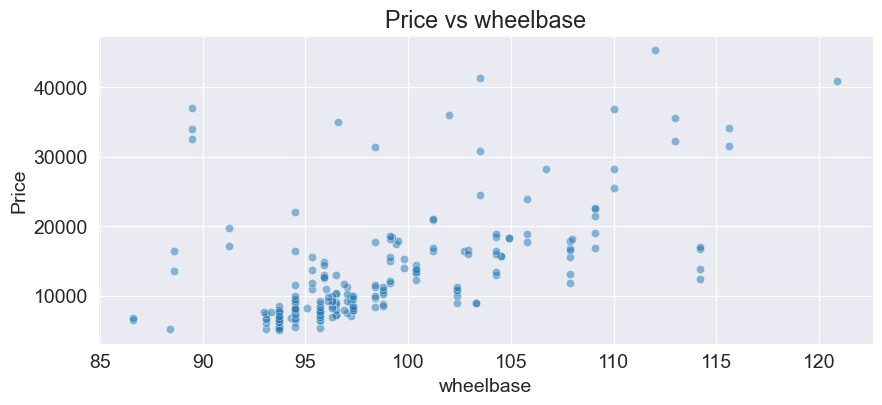

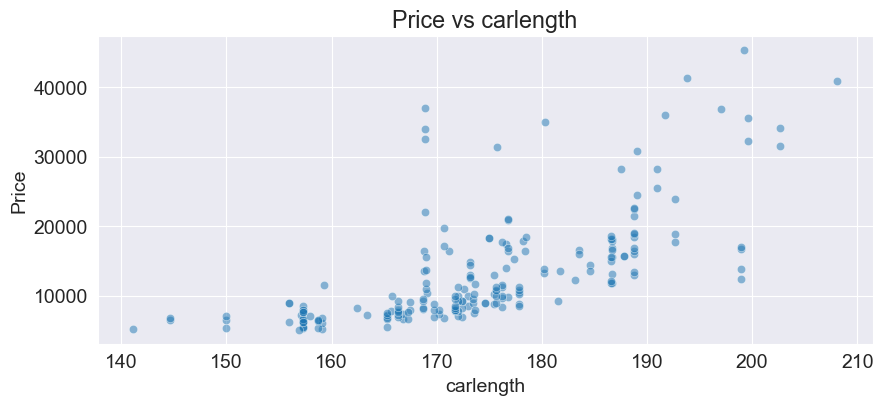

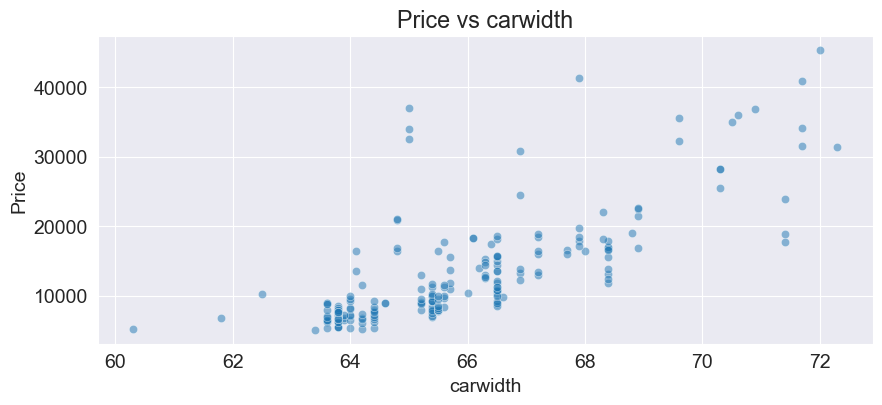

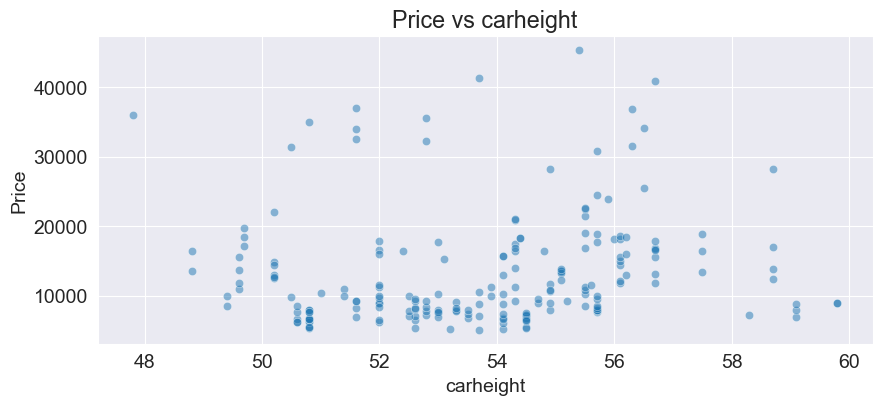

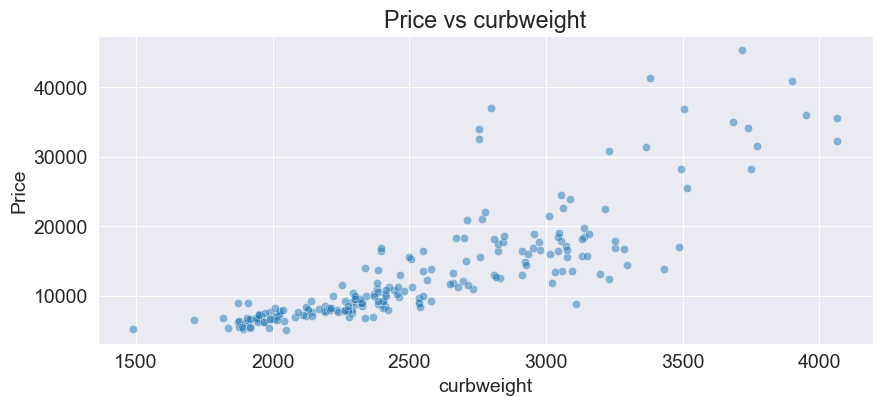

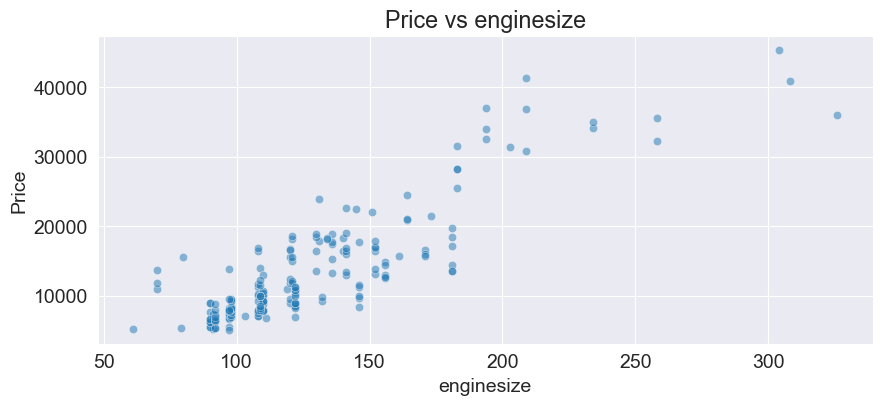

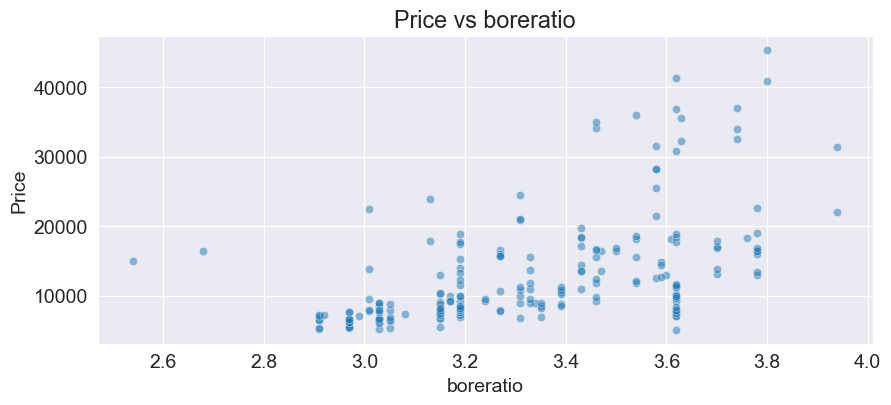

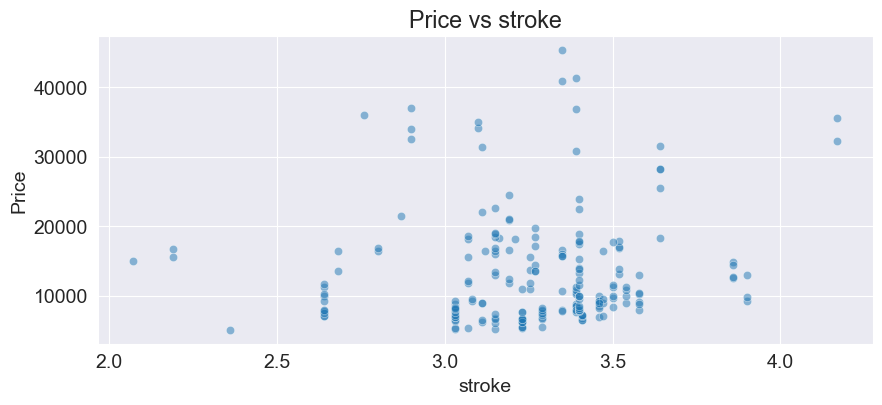

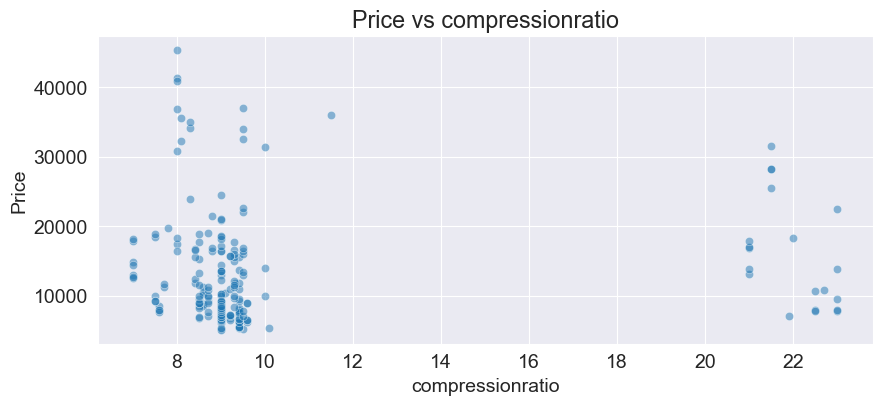

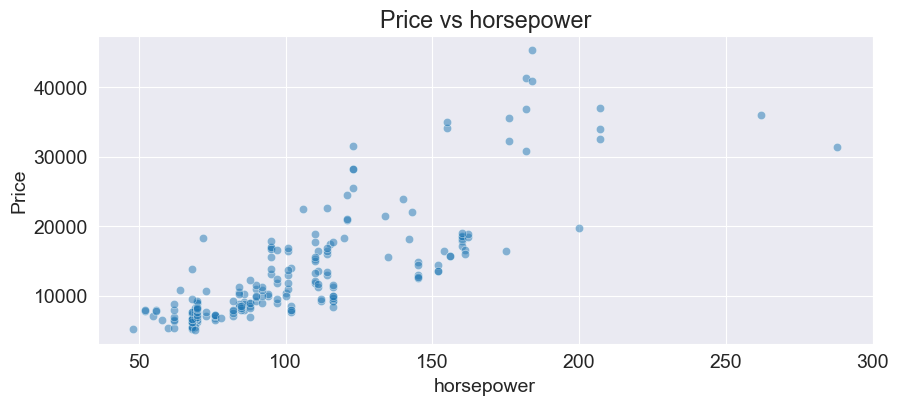

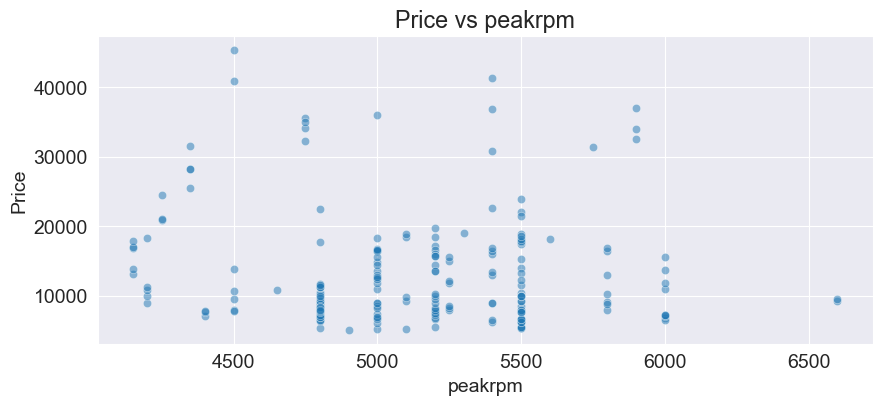

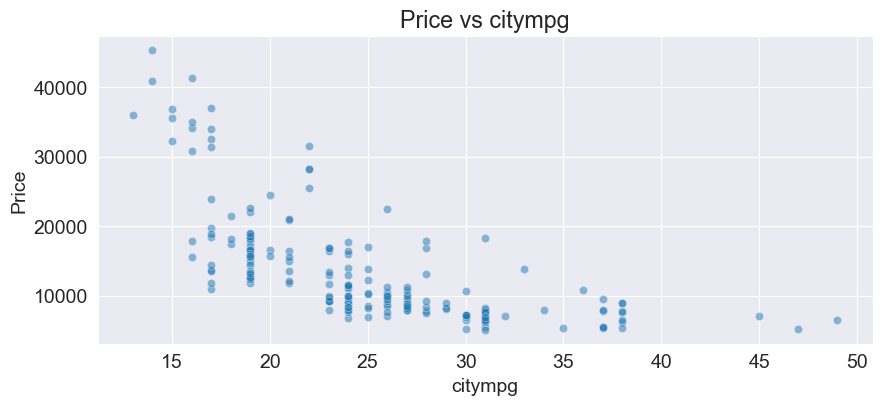

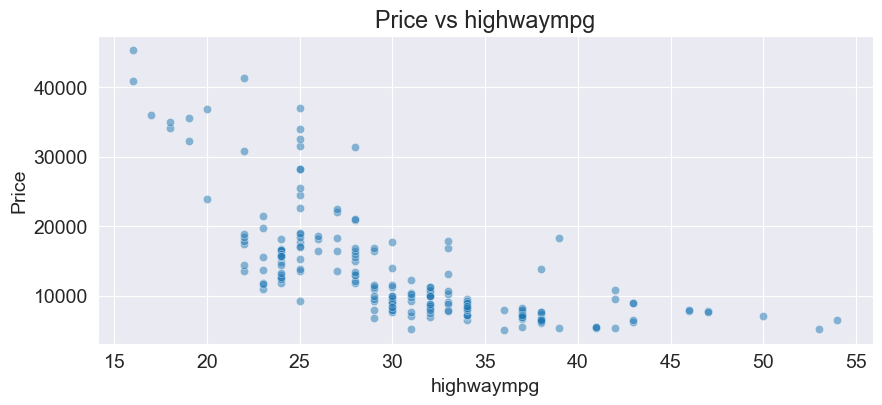

In [12]:
continous_features = [ 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 
                      'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg'
                     ]
for features in continous_features:
    plt.figure(figsize=(10, 4))
    sns.scatterplot(x=car_df[features], y=car_df['price'], alpha=0.5)
    plt.title(f'Price vs {features}')
    plt.xlabel(features)
    plt.ylabel('Price')
    plt.show()

In [13]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [14]:
car_df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

In [15]:
object_data = car_df[['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 
'fuelsystem']]

object_data

,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,enginetype,cylindernumber,fuelsystem
0,alfa-romero giulia,gas,std,two,convertible,rwd,front,dohc,four,mpfi
1,alfa-romero stelvio,gas,std,two,convertible,rwd,front,dohc,four,mpfi
2,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,ohcv,six,mpfi
3,audi 100 ls,gas,std,four,sedan,fwd,front,ohc,four,mpfi
4,audi 100ls,gas,std,four,sedan,4wd,front,ohc,five,mpfi
...,...,...,...,...,...,...,...,...,...,...
200,volvo 145e (sw),gas,std,four,sedan,rwd,front,ohc,four,mpfi
201,volvo 144ea,gas,turbo,four,sedan,rwd,front,ohc,four,mpfi
202,volvo 244dl,gas,std,four,sedan,rwd,front,ohcv,six,mpfi
203,volvo 246,diesel,turbo,four,sedan,rwd,front,ohc,six,idi


In [16]:
def car_name_encoding(data_frame):
    train_set, test_set = train_test_split(car_df, test_size = 0.2, random_state = 42)
    encoder = BinaryEncoder(cols = ['CarName', 'enginetype', 'cylindernumber'])
    encoded_train_set = encoder.fit_transform(train_set)

    encoded_test_set = encoder.fit_transform(test_set)

    return encoded_train_set, encoded_test_set

encoded_train, encoded_test = car_name_encoding(car_df)
encoded_train


,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,fueltype,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
66,67,0,0,0,0,0,0,0,1,diesel,...,134,idi,3.43,3.64,22.0,72,4200,31,39,18344.0
111,112,0,0,0,0,0,0,1,0,gas,...,120,mpfi,3.46,2.19,8.4,95,5000,19,24,15580.0
153,154,0,0,0,0,0,0,1,1,gas,...,92,2bbl,3.05,3.03,9.0,62,4800,31,37,6918.0
96,97,1,0,0,0,0,1,0,0,gas,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,7499.0
38,39,0,0,0,0,0,1,0,1,gas,...,110,1bbl,3.15,3.58,9.0,86,5800,27,33,9095.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,1,1,1,1,0,1,0,gas,...,181,mpfi,3.43,3.27,9.0,160,5200,19,25,18399.0
14,15,1,1,1,1,1,0,1,1,gas,...,164,mpfi,3.31,3.19,9.0,121,4250,20,25,24565.0
92,93,1,0,0,0,0,1,0,0,gas,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,6849.0
179,180,3,1,0,1,0,1,0,0,gas,...,171,mpfi,3.27,3.35,9.3,161,5200,19,24,15998.0


In [17]:
encoded_test

,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,fueltype,aspiration,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
15,16,0,0,0,0,0,0,1,gas,std,...,209,mpfi,3.62,3.390,8.00,182,5400,16,22,30760.000
9,10,0,0,0,0,0,1,0,gas,turbo,...,131,mpfi,3.13,3.400,7.00,160,5500,16,22,17859.167
100,101,0,0,0,0,0,1,1,gas,std,...,120,2bbl,3.33,3.470,8.50,97,5200,27,34,9549.000
132,133,3,0,0,0,1,0,0,gas,std,...,121,mpfi,3.54,3.070,9.31,110,5250,21,28,11850.000
68,69,-1,0,0,0,1,0,1,diesel,turbo,...,183,idi,3.58,3.640,21.50,123,4350,22,25,28248.000
95,96,1,0,0,0,1,1,0,gas,std,...,97,2bbl,3.15,3.290,9.40,69,5200,31,37,7799.000
159,160,0,0,0,0,1,1,1,diesel,std,...,110,idi,3.27,3.350,22.50,56,4500,38,47,7788.000
162,163,0,0,0,1,0,0,0,gas,std,...,98,2bbl,3.19,3.030,9.00,70,4800,28,34,9258.000
147,148,0,0,0,1,0,0,1,gas,std,...,108,mpfi,3.62,2.640,9.00,94,5200,25,31,10198.000
182,183,2,0,0,1,0,1,0,diesel,std,...,97,idi,3.01,3.400,23.00,52,4800,37,46,7775.000


In [18]:
encoded_train.columns

Index(['car_ID', 'symboling', 'CarName_0', 'CarName_1', 'CarName_2',
       'CarName_3', 'CarName_4', 'CarName_5', 'CarName_6', 'fueltype',
       'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation',
       'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginetype_0', 'enginetype_1', 'enginetype_2', 'cylindernumber_0',
       'cylindernumber_1', 'cylindernumber_2', 'enginesize', 'fuelsystem',
       'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm',
       'citympg', 'highwaympg', 'price'],
      dtype='object')

In [19]:
def one_hot_encoding(data_frame, column_name):
    encoding = pd.get_dummies(data_frame, columns = [column_name])
    return encoding

In [20]:
def get_categorical_features(data_frame):
    categorical_colmns = []
    for col in data_frame.columns:
        if pd.api.types.is_categorical_dtype(data_frame[col]) or data_frame[col].dtype == 'object':
            if data_frame[col].nunique() < 10:
                categorical_colmns.append(col)
    return categorical_colmns

In [21]:
categorical_cols = get_categorical_features(encoded_train)
print("Categorical columns:", categorical_cols)

Categorical columns: ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'fuelsystem']


In [22]:
encoded_train

,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,fueltype,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
66,67,0,0,0,0,0,0,0,1,diesel,...,134,idi,3.43,3.64,22.0,72,4200,31,39,18344.0
111,112,0,0,0,0,0,0,1,0,gas,...,120,mpfi,3.46,2.19,8.4,95,5000,19,24,15580.0
153,154,0,0,0,0,0,0,1,1,gas,...,92,2bbl,3.05,3.03,9.0,62,4800,31,37,6918.0
96,97,1,0,0,0,0,1,0,0,gas,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,7499.0
38,39,0,0,0,0,0,1,0,1,gas,...,110,1bbl,3.15,3.58,9.0,86,5800,27,33,9095.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,1,1,1,1,0,1,0,gas,...,181,mpfi,3.43,3.27,9.0,160,5200,19,25,18399.0
14,15,1,1,1,1,1,0,1,1,gas,...,164,mpfi,3.31,3.19,9.0,121,4250,20,25,24565.0
92,93,1,0,0,0,0,1,0,0,gas,...,97,2bbl,3.15,3.29,9.4,69,5200,31,37,6849.0
179,180,3,1,0,1,0,1,0,0,gas,...,171,mpfi,3.27,3.35,9.3,161,5200,19,24,15998.0


In [23]:
for col in categorical_cols:
    encoded_train = one_hot_encoding(encoded_train, col)

In [24]:
encoded_train


,car_ID,symboling,CarName_0,CarName_1,CarName_2,CarName_3,CarName_4,CarName_5,CarName_6,wheelbase,...,enginelocation_front,enginelocation_rear,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
66,67,0,0,0,0,0,0,0,1,104.9,...,True,False,False,False,False,True,False,False,False,False
111,112,0,0,0,0,0,0,1,0,107.9,...,True,False,False,False,False,False,False,True,False,False
153,154,0,0,0,0,0,0,1,1,95.7,...,True,False,False,True,False,False,False,False,False,False
96,97,1,0,0,0,0,1,0,0,94.5,...,True,False,False,True,False,False,False,False,False,False
38,39,0,0,0,0,0,1,0,1,96.5,...,True,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,107,1,1,1,1,1,0,1,0,99.2,...,True,False,False,False,False,False,False,True,False,False
14,15,1,1,1,1,1,0,1,1,103.5,...,True,False,False,False,False,False,False,True,False,False
92,93,1,0,0,0,0,1,0,0,94.5,...,True,False,False,True,False,False,False,False,False,False
179,180,3,1,0,1,0,1,0,0,102.9,...,True,False,False,False,False,False,False,True,False,False


In [25]:
print(type(one_hot_encoding))

<class 'function'>


In [26]:
encoded_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 164 entries, 66 to 102
Data columns (total 53 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   car_ID                164 non-null    int64  
 1   symboling             164 non-null    int64  
 2   CarName_0             164 non-null    int64  
 3   CarName_1             164 non-null    int64  
 4   CarName_2             164 non-null    int64  
 5   CarName_3             164 non-null    int64  
 6   CarName_4             164 non-null    int64  
 7   CarName_5             164 non-null    int64  
 8   CarName_6             164 non-null    int64  
 9   wheelbase             164 non-null    float64
 10  carlength             164 non-null    float64
 11  carwidth              164 non-null    float64
 12  carheight             164 non-null    float64
 13  curbweight            164 non-null    int64  
 14  enginetype_0          164 non-null    int64  
 15  enginetype_1          164 n

In [27]:
car_df.nunique()

car_ID              205
symboling             6
CarName             147
fueltype              2
aspiration            2
doornumber            2
carbody               5
drivewheel            3
enginelocation        2
wheelbase            53
carlength            75
carwidth             44
carheight            49
curbweight          171
enginetype            7
cylindernumber        7
enginesize           44
fuelsystem            8
boreratio            38
stroke               37
compressionratio     32
horsepower           59
peakrpm              23
citympg              29
highwaympg           30
price               189
dtype: int64

In [28]:
car_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

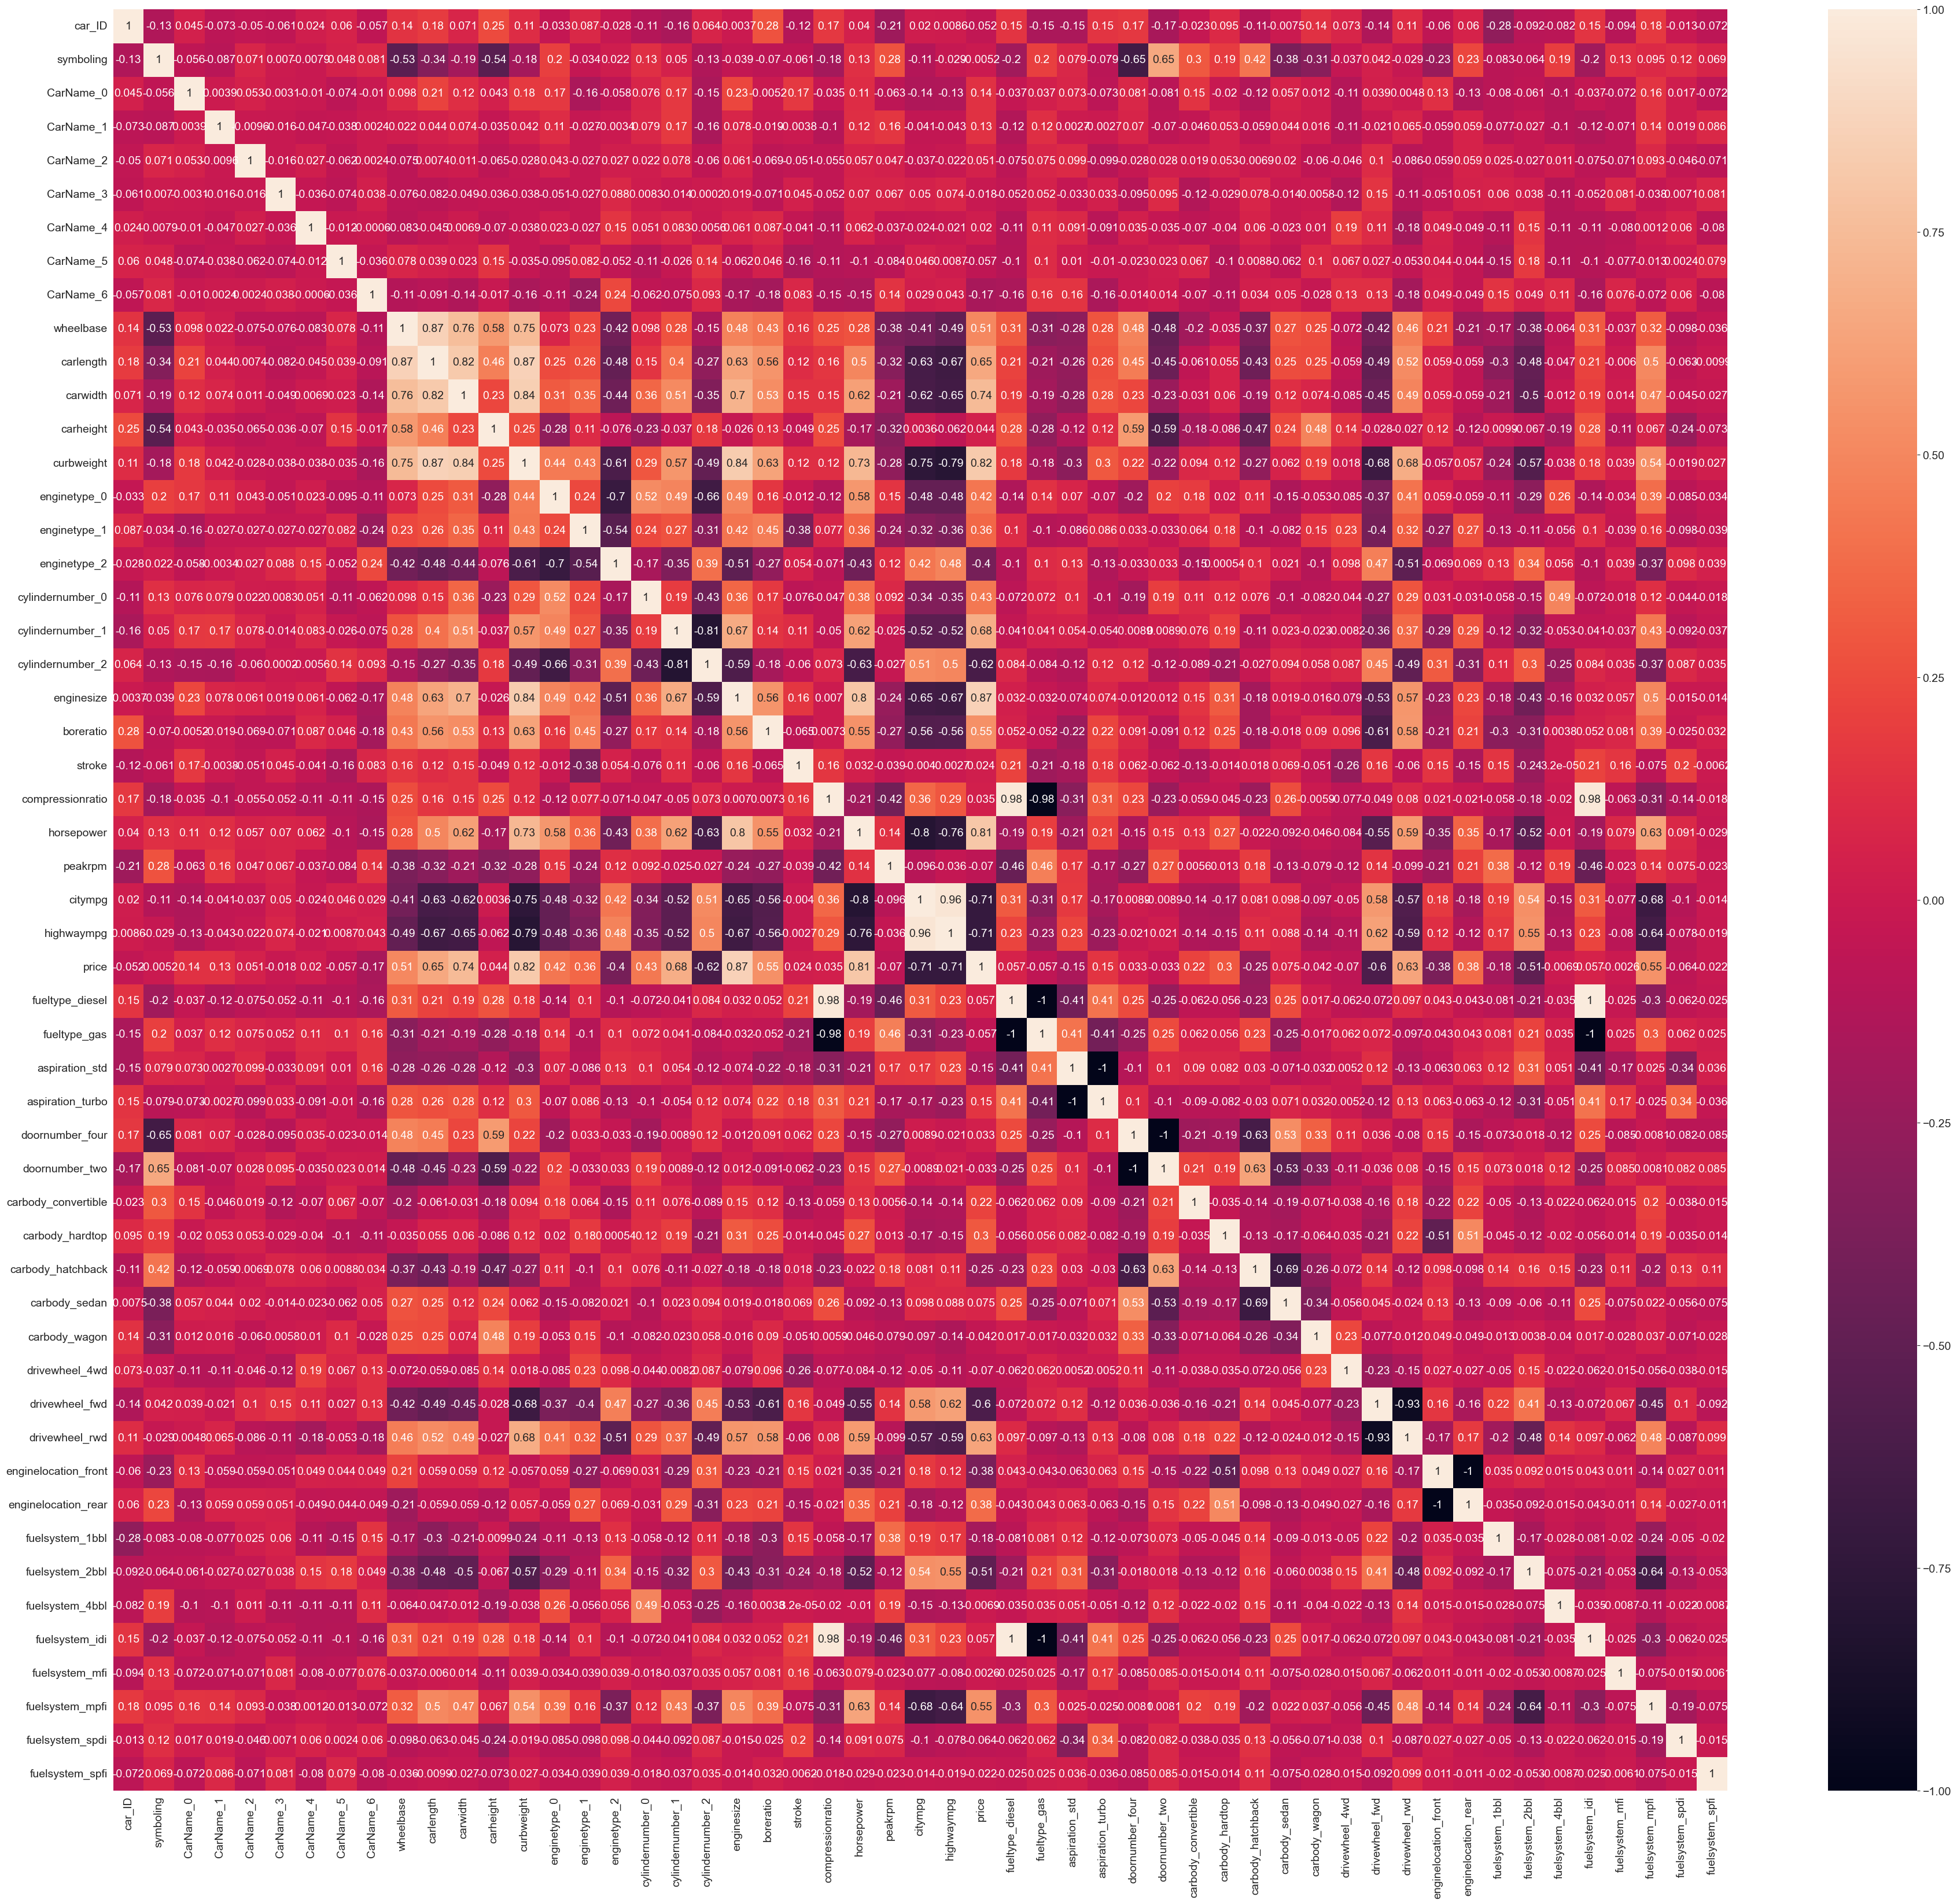

In [29]:
corr_map = encoded_train.corr()
plt.figure(figsize=(45,40))
sns.heatmap(corr_map, annot=True)
plt.show()

In [30]:
def price_features_corr(data_frame, price_column = 'price', correlation_threshold = (0.7, 0.15)):
    correlation_series = data_frame.corr()[price_column].abs().sort_values(ascending = False)
    high_threshold, medium_threshold = correlation_threshold
    high_correlation = list(correlation_series[correlation_series > high_threshold].index[1:])
    medium_correlation = list(correlation_series[(correlation_series <= high_threshold) & (correlation_series > medium_threshold)].index)
    low_correlation = list(correlation_series[(correlation_series < medium_threshold)].index)
    return {
        'high_correlation': high_correlation,
        'medium_correlation': medium_correlation,
        'low_correlation': low_correlation
    }

In [31]:
correlation = price_features_corr(encoded_train)
correlation['high_correlation']

['enginesize', 'curbweight', 'horsepower', 'carwidth', 'highwaympg', 'citympg']

In [32]:
correlation['medium_correlation']

['cylindernumber_1',
 'carlength',
 'drivewheel_rwd',
 'cylindernumber_2',
 'drivewheel_fwd',
 'fuelsystem_mpfi',
 'boreratio',
 'fuelsystem_2bbl',
 'wheelbase',
 'cylindernumber_0',
 'enginetype_0',
 'enginetype_2',
 'enginelocation_rear',
 'enginelocation_front',
 'enginetype_1',
 'carbody_hardtop',
 'carbody_hatchback',
 'carbody_convertible',
 'fuelsystem_1bbl',
 'CarName_6',
 'aspiration_turbo',
 'aspiration_std']

In [33]:
correlation['low_correlation']

['CarName_0',
 'CarName_1',
 'carbody_sedan',
 'peakrpm',
 'drivewheel_4wd',
 'fuelsystem_spdi',
 'fueltype_gas',
 'fueltype_diesel',
 'fuelsystem_idi',
 'CarName_5',
 'car_ID',
 'CarName_2',
 'carheight',
 'carbody_wagon',
 'compressionratio',
 'doornumber_two',
 'doornumber_four',
 'stroke',
 'fuelsystem_spfi',
 'CarName_4',
 'CarName_3',
 'fuelsystem_4bbl',
 'symboling',
 'fuelsystem_mfi']

In [36]:
encoded_train.dtypes

car_ID                    int64
symboling                 int64
CarName_0                 int64
CarName_1                 int64
CarName_2                 int64
CarName_3                 int64
CarName_4                 int64
CarName_5                 int64
CarName_6                 int64
wheelbase               float64
carlength               float64
carwidth                float64
carheight               float64
curbweight                int64
enginetype_0              int64
enginetype_1              int64
enginetype_2              int64
cylindernumber_0          int64
cylindernumber_1          int64
cylindernumber_2          int64
enginesize                int64
boreratio               float64
stroke                  float64
compressionratio        float64
horsepower                int64
peakrpm                   int64
citympg                   int64
highwaympg                int64
price                   float64
fueltype_diesel            bool
fueltype_gas               bool
aspirati

In [48]:
def linear_regression(data_frame):
    x_train = data_frame.drop(['price', 'car_ID'], axis = 1)
    y_train = data_frame['price']


    model = LinearRegression()
    model_fit = model.fit(x_train, y_train)
    
    return model_fit

In [50]:
encoded_train.dtypes

car_ID                    int64
symboling                 int64
CarName_0                 int64
CarName_1                 int64
CarName_2                 int64
CarName_3                 int64
CarName_4                 int64
CarName_5                 int64
CarName_6                 int64
wheelbase               float64
carlength               float64
carwidth                float64
carheight               float64
curbweight                int64
enginetype_0              int64
enginetype_1              int64
enginetype_2              int64
cylindernumber_0          int64
cylindernumber_1          int64
cylindernumber_2          int64
enginesize                int64
boreratio               float64
stroke                  float64
compressionratio        float64
horsepower                int64
peakrpm                   int64
citympg                   int64
highwaympg                int64
price                   float64
fueltype_diesel            bool
fueltype_gas               bool
aspirati

In [54]:
linear_fitted_model = linear_regression(encoded_train)
linear_fitted_model

LinearRegression()